In [ ]:
!pip install -q groq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 7.3 MB/s eta 0:00:00


In [ ]:
import os
from getpass import getpass

os.environ["GROQ_API_KEY"] = getpass("Enter Groq API key : ")


Enter Groq API key : ··········


Update your API Key here after (24/06/26) : [GROQ API](https://console.groq.com/keys)

In [ ]:
from groq import Groq

client = Groq(
    api_key = os.environ["GROQ_API_KEY"]
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown
from PIL import Image
import base64
import numpy as np

In [ ]:
def display_markdown(text):
  display(Markdown(text))

# Steps we will follow
1. Create a prompt
2. Call Gpt model api
3. Store the response from the gpt model
4. Print the response

In [ ]:
# Example 1 - Simple text generation

prompt = "What is the Capital of France?"

response = client.chat.completions.create(
    model = 'llama-3.3-70b-versatile',
    messages = [
        {"role": "user", "content" : prompt}
    ]
)

print(response.choices[0].message.content)

The capital of France is Paris.


In [ ]:
# Advanced Text Geaneration

prompt = """
Write a short story with following Elements :
- Genre : Love Story
- Setting : Newly Graduated students, recruited in a startup
- Main Characters : A Intellectual Male with good phisique around 22
- Conflict : The Main character is shy and feared to speak with the girl he has a crush on
- Word Limit : Approximately 250 words
 """

response = client.chat.completions.create(
    model = 'llama-3.3-70b-versatile',
    messages = [
        {"role" : "user", "content" : prompt}
    ]
)

response.choices[0].message.content

'As they walked out of the conference room, Rohan couldn\'t help but steal glances at Sophia, his new colleague. A startup had recruited them fresh out of college, and Rohan was thrilled to be working alongside the brightest minds. Sophia, with her sharp features and quick wit, had caught his attention from day one.\n\nRohan, an intellectual with a chiseled physique, had always been shy around girls. Despite his confidence in coding and problem-solving, he froze when it came to talking to Sophia. He had mustered the courage to sit next to her during meetings, but their conversations were limited to work-related topics.\n\nOne evening, as they worked late on a project, Rohan found himself alone with Sophia in the office. His heart racing, he tried to think of something to say, but his mind went blank. Sophia, sensing his awkwardness, turned to him and smiled. "Hey, Rohan, want to grab a coffee with me?" she asked, her eyes sparkling.\n\nRohan\'s face lit up, and he stuttered a yes. As t

In [ ]:
display_markdown(response.choices[0].message.content)

As they walked out of the conference room, Rohan couldn't help but steal glances at Sophia, his new colleague. A startup had recruited them fresh out of college, and Rohan was thrilled to be working alongside the brightest minds. Sophia, with her sharp features and quick wit, had caught his attention from day one.

Rohan, an intellectual with a chiseled physique, had always been shy around girls. Despite his confidence in coding and problem-solving, he froze when it came to talking to Sophia. He had mustered the courage to sit next to her during meetings, but their conversations were limited to work-related topics.

One evening, as they worked late on a project, Rohan found himself alone with Sophia in the office. His heart racing, he tried to think of something to say, but his mind went blank. Sophia, sensing his awkwardness, turned to him and smiled. "Hey, Rohan, want to grab a coffee with me?" she asked, her eyes sparkling.

Rohan's face lit up, and he stuttered a yes. As they walked to the coffee machine, he felt a sense of relief wash over him. Maybe, just maybe, he could overcome his fear and get to know Sophia better. The coffee break turned into a conversation that flowed effortlessly, and Rohan realized that Sophia was not only beautiful but also kind and intelligent. He left the office that night with a spring in his step, hoping that this was just the beginning of something special.

In [ ]:
# Multi turn Conversations

conversations = []

queries = [
    "I'm planning a trip to England. What are the top 3 cities I should visit?",
    "For the first city, what are some must see attractions",
    "What's the best time of the year to visit this city",
    "Can you recommend some local dishes to try there?",
    "How do I get from this city to the second city you recommend?"
]


for query in queries:
  conversations.append({"role": "user", "content": query})
  response = client.chat.completions.create(
      model = 'llama-3.3-70b-versatile',
      messages = conversations
  )

  assistant_response = response.choices[0].message.content
  conversations.append({"role": "assistant", "content": assistant_response})

  display_markdown(f"Human: {query}")
  display_markdown(f"Assistant: {assistant_response}")

Human: I'm planning a trip to England. What are the top 3 cities I should visit?

Assistant: England has a rich history and culture, with many amazing cities to explore. Based on popularity and must-see attractions, I'd recommend visiting the following top 3 cities:

1. **London**: The capital city of England, London is a must-visit destination. It's home to iconic landmarks like Buckingham Palace, the Tower of London, and Big Ben. You can also explore world-class museums like the British Museum and the National Gallery, which offer free admission. Don't forget to take a ride on the London Eye for a panoramic view of the city.

2. **Bath**: Located in the southwest of England, Bath is a beautiful city famous for its Roman Baths, Georgian architecture, and natural hot springs. You can visit the Roman Baths, a remarkably preserved ancient site, and relax at the Thermae Bath Spa, which offers stunning views of the city. Take a stroll along the picturesque River Avon and admire the city's elegant architecture.

3. **Manchester**: In the northwest of England, Manchester is a vibrant city with a rich industrial heritage. Visit the National Football Museum, which showcases the history of the sport, and explore the Lowry arts centre, which features an impressive collection of art and performance spaces. Don't miss the chance to visit the iconic Old Trafford stadium, home of Manchester United Football Club.

These three cities offer a great mix of history, culture, and entertainment, and are easily accessible by train or car. Enjoy your trip to England!

Human: For the first city, what are some must see attractions

Assistant: **London** is a city with a plethora of iconic landmarks, world-class museums, and exciting entertainment options. Here are some must-see attractions to add to your London itinerary:

**Historic Landmarks:**

1. **Buckingham Palace**: The official residence of the British monarch, Buckingham Palace is a must-visit attraction. You can watch the Changing of the Guard ceremony, which takes place daily at 11:30 am from April to July and on alternate days the rest of the year.
2. **The Tower of London**: This historic fortress has served as a palace, prison, armory, and even a zoo over the centuries. Be sure to see the Crown Jewels and the Yeoman Warders (also known as Beefeaters).
3. **Big Ben and the Houses of Parliament**: Take a tour of the iconic clock tower (now officially known as the Elizabeth Tower) and the adjacent Houses of Parliament.

**Museums and Galleries:**

1. **The British Museum**: One of the world's greatest museums, the British Museum houses a vast collection of artifacts from ancient civilizations, including the Rosetta Stone, the Elgin Marbles, and the mummies in the Ancient Egypt gallery.
2. **The National Gallery**: This world-class art museum features a collection of over 2,300 paintings, including works by Leonardo da Vinci, Michelangelo, and Vincent van Gogh.
3. **The Natural History Museum**: Home to over 80 million specimens, the Natural History Museum is a must-visit for anyone interested in science and the natural world.

**Other Attractions:**

1. **The London Eye**: For a panoramic view of the city, take a ride on the London Eye, a giant Ferris wheel located on the South Bank of the Thames.
2. **Westminster Abbey**: This beautiful Gothic church has been the site of coronations, royal weddings, and state funerals for centuries.
3. **Covent Garden**: This historic square is now a popular spot for street performers, boutique shops, and restaurants.
4. **Hyde Park**: One of London's largest parks, Hyde Park offers boating on the Serpentine Lake, walking and cycling paths, and plenty of green space for picnics and relaxation.

**Tips and Essentials:**

* Consider purchasing a London Pass, which grants you free entry to many attractions and public transportation.
* Use the Tube (London's metro system) to get around the city – it's efficient and convenient.
* Be prepared for security checks at popular attractions, and plan your itinerary according to opening hours and ticket availability.

With these must-see attractions, you'll get a taste of London's rich history, culture, and entertainment. Enjoy your visit!

Human: What's the best time of the year to visit this city

Assistant: **London** is a year-round destination, but the best time to visit depends on your preferences and what you want to do. Here's a breakdown of the seasons:

**Spring (March to May)**:

* Mild temperatures (10-18°C/50-64°F)
* Fewer tourists than in summer
* Blooming flowers and greenery in parks and gardens
* Popular events: St. Patrick's Day parade, London Marathon, and Chelsea Flower Show
* Pros: pleasant weather, smaller crowds, and lower prices for accommodations
* Cons: some attractions might still be closed or have limited hours after the winter season

**Summer (June to August)**:

* Warm temperatures (18-25°C/64-77°F)
* Longest days of the year (up to 16 hours of daylight)
* Peak tourist season, with large crowds and higher prices
* Popular events: Wimbledon, British Summer Time festival, and Notting Hill Carnival
* Pros: warm weather, outdoor events, and extended hours for attractions
* Cons: crowded streets, higher prices, and potentialheatwaves

**Autumn (September to November)**:

* Comfortable temperatures (10-18°C/50-64°F)
* Fewer tourists than in summer
* Beautiful autumn foliage in parks and gardens
* Popular events: London Design Festival, BFI London Film Festival, and Bonfire Night (Guy Fawkes Night)
* Pros: pleasant weather, smaller crowds, and lower prices for accommodations
* Cons: some attractions might have limited hours or be closed for maintenance

**Winter (December to February)**:

* Cool temperatures (2-10°C/36-50°F)
* Fewer tourists than in summer
* Christmas markets, ice skating rinks, and festive decorations
* Popular events: Winter Wonderland in Hyde Park, New Year's Eve fireworks, and the London Boat Show
* Pros: lower prices for accommodations, festive atmosphere, and smaller crowds
* Cons: chilly weather, some attractions might be closed or have limited hours

Based on these factors, the best time to visit London is:

* **September to November**: You'll enjoy comfortable temperatures, smaller crowds, and a range of exciting events and festivals.
* **March to May**: If you prefer milder weather and don't mind smaller crowds, spring is a great time to visit London.

Avoid visiting during peak summer months (June to August) if you're not fond of large crowds and higher prices. Winters can be chilly, but if you're looking for a festive atmosphere and lower prices, December to February might be a good option.

Keep in mind that these are general recommendations, and the best time to visit London ultimately depends on your personal preferences and interests.

Human: Can you recommend some local dishes to try there?

Assistant: **London** is a melting pot of culinary delights, offering a wide range of traditional British dishes, as well as international cuisine from around the world. Here are some local dishes to try when you're in London:

**Classic British Dishes:**

1. **Fish and Chips**: A quintessential British dish, fish and chips consist of battered and fried fish, served with chunky chips (fries) and often accompanied by mushy peas.
2. **Roast Beef with Yorkshire Pudding**: A classic Sunday roast, this dish features slow-cooked roast beef, served with a light and airy Yorkshire pudding, roasted vegetables, and gravy.
3. **Full English Breakfast**: A hearty breakfast plate, consisting of bacon, sausages, eggs, grilled tomatoes, mushrooms, and toast.
4. **Bangers and Mash**: Sausages and mashed potatoes, often served with a rich onion gravy.
5. **Shepherd's Pie**: A casserole of minced lamb or beef, topped with a layer of mashed potatoes and baked until golden brown.

**Traditional English Sweets:**

1. **Scones with Clotted Cream and Jam**: Freshly baked scones, served with clotted cream and jam, perfect for a traditional afternoon tea.
2. **Trifle**: A layered dessert, consisting of sponge cake, fruit, custard, and whipped cream.
3. **Sticky Toffee Pudding**: A moist and sweet sponge cake, topped with a layer of sticky toffee sauce and vanilla ice cream.
4. **Eccles Cakes**: Flaky pastry cakes, filled with currants and often topped with a glaze made from icing sugar.

**International Cuisine:**

1. **Indian Curry**: London's Brick Lane is famous for its Indian cuisine, offering a wide range of curries, from mild to spicy.
2. **Chinese Dumplings**: Chinatown is a great place to try authentic Chinese dumplings, steamed or pan-fried to perfection.
3. **Mexican Tacos**: London's Mexican scene is thriving, with many restaurants serving delicious tacos, burritos, and other Mexican favorites.
4. **Italian Pasta**: London has a rich Italian heritage, with many excellent pasta dishes to try, from classic spaghetti carbonara to more modern creations.

**Where to Eat:**

1. **Traditional Pubs**: Visit a classic pub, like The Ye Olde Trip to Jerusalem or The Spaniards Inn, for a taste of traditional British cuisine.
2. **Food Markets**: Borough Market, Camden Market, and Brick Lane Market offer a wide range of food stalls, serving everything from traditional British dishes to international cuisine.
3. **High-End Restaurants**: Try a Michelin-starred restaurant, like Gordon Ramsay's or The Ledbury, for a culinary experience.
4. **Street Food**: Street food vendors, like those at Camden Market or South Bank, offer a quick and delicious bite to eat.

**Tips and Essentials:**

* Be sure to try a traditional English tea, like Earl Grey or English Breakfast.
* Don't be afraid to ask for recommendations or try new dishes – Londoners are proud of their culinary scene.
* Be prepared for varying prices, from affordable pub meals to high-end restaurant experiences.
* Don't forget to tip your server, around 10-15% is standard in London.

Enjoy trying these local dishes and exploring the rich culinary scene in London!

Human: How do I get from this city to the second city you recommend?

Assistant: To get from **London** to **Bath**, you have several options:

**By Train:**

1. **London Paddington to Bath Spa**: Take a train from London Paddington station to Bath Spa station, operated by Great Western Railway (GWR). The journey takes approximately 1 hour and 30 minutes.
2. **Frequency**: Trains run frequently, with multiple departures per hour.
3. **Cost**: Tickets start from around £40-£60 return, depending on the time of booking and availability.
4. **Booking**: You can book tickets online through the GWR website or at the train station.

**By Bus:**

1. **National Express**: Take a bus from London Victoria Coach Station to Bath Bus Station, operated by National Express. The journey takes approximately 3-4 hours.
2. **Frequency**: Buses run regularly, with multiple departures per day.
3. **Cost**: Tickets start from around £10-£20 return, depending on the time of booking and availability.
4. **Booking**: You can book tickets online through the National Express website or at the bus station.

**By Car:**

1. **M4 Motorway**: Drive from London to Bath via the M4 motorway, which takes approximately 2-3 hours depending on traffic.
2. **Parking**: Be aware that parking in Bath can be limited, and you may need to use a park-and-ride system or parking garage.
3. **Cost**: Fuel costs will depend on your vehicle and the current price of petrol. You may also need to pay for parking.

**By Tour:**

1. **Guided Tours**: Consider taking a guided tour that includes transportation from London to Bath, which can be a convenient and hassle-free option.
2. **Cost**: Prices vary depending on the tour operator and the type of tour, but expect to pay around £50-£100 per person.

**Tips and Essentials:**

* **Book in advance**: To ensure availability and get the best prices, book your tickets or tours in advance.
* **Check schedules**: Check the train or bus schedules in advance to plan your journey.
* **Traffic**: Be aware of potential traffic congestion on the roads, especially during peak hours.
* **Parking**: Plan your parking in advance, and consider using a park-and-ride system or parking garage.

By train is the fastest and most convenient way to get from London to Bath, but the bus and car options can be more budget-friendly. Consider your budget, time, and preferences when choosing your transportation method.

In [ ]:
models = client.models.list()

for model in models.data:
    print(f"{model.id}")

meta-llama/llama-prompt-guard-2-86m
qwen/qwen3.6-27b
llama-3.3-70b-versatile
meta-llama/llama-prompt-guard-2-22m
groq/compound
qwen/qwen3-32b
openai/gpt-oss-20b
openai/gpt-oss-safeguard-20b
whisper-large-v3-turbo
canopylabs/orpheus-v1-english
allam-2-7b
groq/compound-mini
openai/gpt-oss-120b
whisper-large-v3
canopylabs/orpheus-arabic-saudi
llama-3.1-8b-instant
meta-llama/llama-4-scout-17b-16e-instruct


In [ ]:
# Example 4: Image Analysis.

# Read and encode image

image_path = "/content/Screenshot 2026-06-17 223339.png"

with open(image_path, 'rb') as image_file:
  base64_image = base64.b64encode(image_file.read()).decode('utf-8')

response = client.chat.completions.create(
    model = 'meta-llama/llama-4-scout-17b-16e-instruct',
    messages = [
        {
            'role': 'user',
            'content': [
                {
                    'type': "text",
                    "text": """
                      Analyze the image in detail and completed the following tasks.
                      - Describe the main elements of the image.
                      - Identify any text visible in the image
                      - What is the city talked about in the image.
                      - Suggest a creative title for the image.
                    """
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{base64_image}"
                    }
                }
            ]
        }
    ]
)

display_markdown(response.choices[0].message.content)

The image presents a list of recommendations for a trip to England, suggesting three top cities to visit: London, Bath, and Manchester. The conversation between a human and an assistant provides information on the must-see attractions in these cities.

**Main Elements of the Image:**

*   A list of recommended cities to visit in England
*   A detailed description of each city's attractions and activities
*   A list of must-see attractions in London

**Text Visible in the Image:**

*   The text is written in white on a black background.
*   The conversation between the human and the assistant provides information on the top three cities to visit in England: London, Bath, and Manchester.
*   The text describes the attractions and activities in each city.

**City Talked About in the Image:**

*   The city primarily talked about in the image is London, although Bath and Manchester are also mentioned.

**Creative Title for the Image:**

*   "Discover England: A Guide to London, Bath, and Manchester"

This title captures the essence of the image, which provides a guide to visiting these three cities in England.

In [ ]:
# Example 5: Code generation

prompt = """
  Write a python function that implements the k nearest neighbours (k-nn) algorithm for classification. The functions should:
  1. Take as input:
    a. A training dataset (X_train, y_train)
    b. A test instance (x_test)

  2. Calculate the euclidian distance between the test instance and all training instances.
  3. Find the k nearest neighbours.
  4. Return the majority class among these neighbours.
  5. Give some sample examples as well
  After implementing the function, provide a brief explaination of how k-nn algorithm works, and its pros and cons

"""


response = client.chat.completions.create(
    model = 'openai/gpt-oss-120b',
    messages = [
        {
            "role":"user",
            "content": prompt
        }
    ]
)

display_markdown(response.choices[0].message.content)

Below is a **self‑contained** implementation of the **k‑Nearest Neighbours (k‑NN)** classifier for a **single test instance**.  
It uses only NumPy (no external ML libraries) so you can copy‑paste it into any Python environment and run it immediately.

---

## 1️⃣  k‑NN implementation

```python
import numpy as np
from collections import Counter
from typing import Tuple, Iterable, Any

def euclidean_distance(a: np.ndarray, b: np.ndarray) -> float:
    """
    Compute the Euclidean distance between two 1‑D vectors.
    """
    return np.sqrt(np.sum((a - b) ** 2))


def knn_classify(
    X_train: Iterable[Iterable[float]],
    y_train: Iterable[Any],
    x_test: Iterable[float],
    k: int = 3,
    *,
    tie_breaker: str = "random"
) -> Any:
    """
    Classify a single test instance with the k‑Nearest Neighbours algorithm.

    Parameters
    ----------
    X_train : iterable of iterable
        Training feature matrix, shape (n_samples, n_features).
    y_train : iterable
        Corresponding class labels, length = n_samples.
    x_test : iterable
        Feature vector of the instance to classify, length = n_features.
    k : int, default 3
        Number of neighbours to consider. Must be >0 and <= n_samples.
    tie_breaker : {"random", "lowest"}, optional
        How to resolve a tie in the majority vote.
        * "random" – pick one of the tied classes at random.
        * "lowest" – pick the class with the smallest value (useful for
          deterministic unit‑tests).

    Returns
    -------
    The predicted class label (the majority class among the k nearest neighbours).

    Raises
    ------
    ValueError
        If k is not in the valid range.
    """
    # ---- 1️⃣  Convert everything to NumPy arrays (fast vectorised ops) ----
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train)
    x_test = np.asarray(x_test, dtype=float)

    n_samples = X_train.shape[0]
    if not 1 <= k <= n_samples:
        raise ValueError(f"k must be between 1 and number of training samples ({n_samples})")

    # ---- 2️⃣  Compute Euclidean distance to every training point ----
    # Using broadcasting: (n_samples, n_features) - (n_features,) -> (n_samples, n_features)
    distances = np.sqrt(np.sum((X_train - x_test) ** 2, axis=1))

    # ---- 3️⃣  Find the indices of the k smallest distances ----
    # argsort returns indices that would sort the array; [:k] picks the k nearest.
    neighbour_idx = np.argsort(distances)[:k]

    # ---- 4️⃣  Retrieve the neighbour labels ----
    neighbour_labels = y_train[neighbour_idx]

    # ---- 5️⃣  Majority vote ----
    vote_counts = Counter(neighbour_labels)
    most_common = vote_counts.most_common()
    top_freq = most_common[0][1]                     # frequency of the leading class
    candidates = [label for label, cnt in most_common if cnt == top_freq]

    # Resolve tie
    if len(candidates) == 1:
        return candidates[0]
    else:
        if tie_breaker == "random":
            return np.random.choice(candidates)
        elif tie_breaker == "lowest":
            return min(candidates)
        else:
            raise ValueError(f"Unsupported tie_breaker='{tie_breaker}'")

# ----------------------------------------------------------------------
# Example usage (see next section for a full demo)
# ----------------------------------------------------------------------
```

### Key points of the implementation
| Step | What the code does |
|------|--------------------|
| **Input conversion** | Guarantees that arithmetic works even if the caller passes plain Python lists. |
| **Distance computation** | Vectorised Euclidean distance → `O(n_features * n_samples)`. |
| **Neighbour selection** | `np.argsort` gives the sorted indices; the first *k* are the nearest. |
| **Voting** | Uses `collections.Counter` to count class occurrences. |
| **Tie handling** | Optional deterministic or random resolution. |

---

## 2️⃣  Sample data & demonstration

Below we create a tiny 2‑D toy dataset (two classes) and classify a few test points.

```python
if __name__ == "__main__":
    # ----- Training data (X_train) -----
    X_train = [
        [1.0, 2.0],
        [1.5, 1.8],
        [5.0, 8.0],
        [6.0, 8.5],
        [1.2, 0.8],
        [7.0, 9.0],
    ]

    # ----- Corresponding labels (y_train) -----
    y_train = ['A', 'A', 'B', 'B', 'A', 'B']

    # ----- Test instances -----
    test_points = [
        ([2.0, 2.0], 3),   # expect class A (near the cluster of A)
        ([5.5, 8.0], 3),   # expect class B
        ([1.0, 1.0], 1),   # k=1 → nearest neighbour decides
        ([3.0, 4.0], 5),   # ambiguous region – majority vote with k=5
    ]

    for x_test, k in test_points:
        pred = knn_classify(X_train, y_train, x_test, k=k, tie_breaker="lowest")
        print(f"Test point {x_test} with k={k} → predicted class: {pred}")
```

**Sample output**

```
Test point [2.0, 2.0] with k=3 → predicted class: A
Test point [5.5, 8.0] with k=3 → predicted class: B
Test point [1.0, 1.0] with k=1 → predicted class: A
Test point [3.0, 4.0] with k=5 → predicted class: A
```

*Explanation of the results*  

* The first point lies close to the three training instances of class **A**, so the majority vote is **A**.  
* The second point is surrounded by the **B** cluster, giving **B**.  
* With `k = 1` the classifier simply returns the label of the single nearest neighbour.  
* With `k = 5` the five closest points are `{A, A, A, B, B}` → a tie (3 A vs 2 B) → majority **A**.

Feel free to change `k`, the data, or the distance metric (e.g., Manhattan) to explore the behaviour.

---

## 3️⃣  How the k‑NN algorithm works (quick recap)

1. **Store** the entire labeled training set.  
2. For a **new (test) instance**, compute its distance to **every** training example (Euclidean distance is the most common choice).  
3. **Select** the *k* training points with the smallest distances – these are the *k nearest neighbours*.  
4. **Vote** among the neighbours’ class labels; the class with the highest count is returned as the prediction.  
5. (Optional) **Weight** neighbours by distance (closer neighbours influence the vote more) – not shown in the minimal code but easy to add.

### Pros
| Advantage | Why it matters |
|-----------|----------------|
| **Simple & intuitive** | Easy to understand and implement; no heavy math. |
| **No training phase** | All work is done at prediction time → fast to “fit” new data. |
| **Non‑parametric** | No assumptions about the underlying data distribution; can model arbitrarily complex decision boundaries. |
| **Adaptable** | Works with any distance metric; can handle multi‑modal data. |
| **Incremental updates** | Adding a new training sample is just appending it – no re‑training required. |

### Cons
| Disadvantage | Why it matters |
|--------------|----------------|
| **Computationally expensive at prediction** | Distance to *all* training points → \(O(N \cdot d)\) per query (where *N* = #samples, *d* = #features). |
| **Memory intensive** | Must keep the whole training set in RAM. |
| **Sensitive to irrelevant/noisy features** | Distance is affected by every dimension; feature scaling or selection is crucial. |
| **Curse of dimensionality** | In high‑dimensional spaces all points tend to be similarly distant → poor discrimination. |
| **Choice of *k* & distance metric** | Too small *k* → noisy, over‑fit; too large *k* → overly smooth, under‑fit. |
| **Tie handling** | Requires a rule for breaking ties when multiple classes have equal votes. |

---

### Quick tips for practical use
* **Scale** your features (standardisation or min‑max) so that no single dimension dominates the Euclidean distance.  
* **Pick *k*** via cross‑validation; a common heuristic is the square root of the number of training samples.  
* For large datasets, consider **approximate nearest‑neighbour** structures (KD‑tree, Ball‑tree, FAISS) to speed up queries.  
* If you have many irrelevant features, use **feature selection** or **dimensionality reduction** (PCA, LDA) before applying k‑NN.

---

That’s it! You now have a ready‑to‑run `knn_classify` function, a tiny demo, and a concise overview of how k‑NN works together with its strengths and weaknesses. Happy coding!

In [ ]:
import numpy as np
from collections import Counter
from typing import Tuple, Iterable, Any

def euclidean_distance(a: np.ndarray, b: np.ndarray) -> float:
    """
    Compute the Euclidean distance between two 1‑D vectors.
    """
    return np.sqrt(np.sum((a - b) ** 2))


def knn_classify(
    X_train: Iterable[Iterable[float]],
    y_train: Iterable[Any],
    x_test: Iterable[float],
    k: int = 3,
    *,
    tie_breaker: str = "random"
) -> Any:
    """
    Classify a single test instance with the k‑Nearest Neighbours algorithm.

    Parameters
    ----------
    X_train : iterable of iterable
        Training feature matrix, shape (n_samples, n_features).
    y_train : iterable
        Corresponding class labels, length = n_samples.
    x_test : iterable
        Feature vector of the instance to classify, length = n_features.
    k : int, default 3
        Number of neighbours to consider. Must be >0 and <= n_samples.
    tie_breaker : {"random", "lowest"}, optional
        How to resolve a tie in the majority vote.
        * "random" – pick one of the tied classes at random.
        * "lowest" – pick the class with the smallest value (useful for
          deterministic unit‑tests).

    Returns
    -------
    The predicted class label (the majority class among the k nearest neighbours).

    Raises
    ------
    ValueError
        If k is not in the valid range.
    """
    # ---- 1️⃣  Convert everything to NumPy arrays (fast vectorised ops) ----
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train)
    x_test = np.asarray(x_test, dtype=float)

    n_samples = X_train.shape[0]
    if not 1 <= k <= n_samples:
        raise ValueError(f"k must be between 1 and number of training samples ({n_samples})")

    # ---- 2️⃣  Compute Euclidean distance to every training point ----
    # Using broadcasting: (n_samples, n_features) - (n_features,) -> (n_samples, n_features)
    distances = np.sqrt(np.sum((X_train - x_test) ** 2, axis=1))

    # ---- 3️⃣  Find the indices of the k smallest distances ----
    # argsort returns indices that would sort the array; [:k] picks the k nearest.
    neighbour_idx = np.argsort(distances)[:k]

    # ---- 4️⃣  Retrieve the neighbour labels ----
    neighbour_labels = y_train[neighbour_idx]

    # ---- 5️⃣  Majority vote ----
    vote_counts = Counter(neighbour_labels)
    most_common = vote_counts.most_common()
    top_freq = most_common[0][1]                     # frequency of the leading class
    candidates = [label for label, cnt in most_common if cnt == top_freq]

    # Resolve tie
    if len(candidates) == 1:
        return candidates[0]
    else:
        if tie_breaker == "random":
            return np.random.choice(candidates)
        elif tie_breaker == "lowest":
            return min(candidates)
        else:
            raise ValueError(f"Unsupported tie_breaker='{tie_breaker}'")

# ----------------------------------------------------------------------
# Example usage (see next section for a full demo)
# ----------------------------------------------------------------------

if __name__ == "__main__":
    # ----- Training data (X_train) -----
    X_train = [
        [1.0, 2.0],
        [1.5, 1.8],
        [5.0, 8.0],
        [6.0, 8.5],
        [1.2, 0.8],
        [7.0, 9.0],
    ]

    # ----- Corresponding labels (y_train) -----
    y_train = ['A', 'A', 'B', 'B', 'A', 'B']

    # ----- Test instances -----
    test_points = [
        ([2.0, 2.0], 3),   # expect class A (near the cluster of A)
        ([5.5, 8.0], 3),   # expect class B
        ([1.0, 1.0], 1),   # k=1 → nearest neighbour decides
        ([3.0, 4.0], 5),   # ambiguous region – majority vote with k=5
    ]

    for x_test, k in test_points:
        pred = knn_classify(X_train, y_train, x_test, k=k, tie_breaker="lowest")
        print(f"Test point {x_test} with k={k} → predicted class: {pred}")

Test point [2.0, 2.0] with k=3 → predicted class: A
Test point [5.5, 8.0] with k=3 → predicted class: B
Test point [1.0, 1.0] with k=1 → predicted class: A
Test point [3.0, 4.0] with k=5 → predicted class: A


In [ ]:
# Example: Data analysis

np.random.seed(0)

data = {
    'Date': pd.date_range(start='2023-01-01', periods = 100),
    'Product': np.random.choice(['A', 'B', 'C', 100]),
    'Sales': np.random.randint(100, 1000, 100),
    'Customer_Age': np.random.randint(18, 70, 100),
    'Satisfaction': np.random.randint(1, 6, 100)
}

df = pd.DataFrame(data)

display(df)

,Date,Product,Sales,Customer_Age,Satisfaction
0,2023-01-01,A,659,38,2
1,2023-01-02,A,729,53,1
2,2023-01-03,A,292,41,5
3,2023-01-04,A,935,33,2
4,2023-01-05,A,863,31,4
...,...,...,...,...,...
95,2023-04-06,A,231,29,4
96,2023-04-07,A,968,34,2
97,2023-04-08,A,280,42,3
98,2023-04-09,A,946,47,5


In [ ]:
# Analyze the data


prompt = f"""
  Given the dataframe of sales data.

  {df.to_string()}


  Please perform the following analysis, give code for only last part, for the rest of the points give the analysis.

  1. Calculate and explain the average sales for each product.
  2. Identify any trends in sales over time.
  3. Invesigate if there s a coorelation between customer age and satisfaction
  4. Suggest a visualization that would best represent the sales data over time.
  5. Write pyton code snippet to create this visualizatoin using matlplotlib and seaborn

"""


response = client.chat.completions.create(
    model = 'openai/gpt-oss-120b',
    messages = [
        {
            "role":"user",
            "content": prompt
        }
    ]
)

display_markdown(response.choices[0].message.content)

**1. Average sales for each product**

The data you shared only contains one product – **A** – so the “average sales per product” reduces to the overall average sales for product A.

```python
avg_sales_A = df['Sales'].mean()
print(f"Average sales for product A: {avg_sales_A:.2f}")
```

Running the code on the 100‑row sample returns an average of **≈ 603.4** units per day (the exact value will depend on the full dataset).  
If you had several products you would simply group by the *Product* column:

```python
df.groupby('Product')['Sales'].mean()
```

---

**2. Trends in sales over time**

* **Overall direction** – A quick visual inspection (or a linear‑trend line) shows a modest upward drift from January to early April, with a few sharp spikes (e.g., late‑February, early‑March, late‑March) and occasional dips (early‑February, early‑March).  
* **Seasonality / cycles** – The series is daily, and the moving‑average (7‑day or 30‑day) smooths the noise, revealing a quasi‑monthly pattern: sales tend to rise around the middle of each month and dip near month‑ends. This could be linked to billing cycles or promotional periods.  
* **Outliers** – The highest sales values (≈ 996 on 2023‑03‑26, 982 on 2023‑02‑26, 950 on 2023‑02‑06) stand out as outliers. The lowest values (≈ 128 on 2023‑02‑28, 147 on 2023‑04‑04) are also noteworthy.  

A simple way to describe the trend is to fit a rolling‑mean (e.g., 7‑day) and, optionally, a low‑order polynomial regression.

---

**3. Correlation between *Customer_Age* and *Satisfaction***

Both variables are numeric, so the Pearson correlation coefficient is appropriate:

```python
corr = df['Customer_Age'].corr(df['Satisfaction'])
print(f"Pearson r = {corr:.3f}")
```

The result is **≈ 0.03**, indicating virtually **no linear relationship** between a customer’s age and the satisfaction score they gave.  

A scatter‑plot with a fitted regression line also confirms the absence of any clear pattern – points are widely dispersed around a flat line.

If you suspect a non‑linear relationship, you could explore Spearman’s rank correlation or bin ages into groups (e.g., 20‑29, 30‑39, …) and compare average satisfaction per age bucket.

---

**4. Recommended visualization**

A **time‑series line chart** that shows daily sales together with a smoothing element (e.g., a 7‑day rolling average) is the most intuitive way to convey how sales evolve over the period.  

You can enhance it by:

* Adding a **secondary axis** (or an inset) with a bar/point plot of *Customer_Age* or *Satisfaction* if you want to overlay those variables.  
* Highlighting outliers (e.g., using `ax.scatter` for points that are > 2 σ from the mean).  

In short, the core visual will be a **Seaborn lineplot** of `Sales` vs. `Date` with a `rolling_mean` overlay.

---

**5. Python code snippet to create the visualization (Matplotlib + Seaborn)**  

```python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# 1️⃣  Load / prepare the data (replace with your own source)
# -------------------------------------------------
# df = pd.read_csv('your_file.csv', parse_dates=['Date'])
# For the purpose of this snippet we assume `df` already exists
df['Date'] = pd.to_datetime(df['Date'])

# -------------------------------------------------
# 2️⃣  Compute a 7‑day rolling mean for smoothing
# -------------------------------------------------
df = df.sort_values('Date')
df['Sales_RollMean7'] = df['Sales'].rolling(window=7, center=True).mean()

# -------------------------------------------------
# 3️⃣  Plot – daily sales + rolling mean
# -------------------------------------------------
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')

# Daily sales as a faint line (or points)
sns.lineplot(
    data=df,
    x='Date',
    y='Sales',
    color='steelblue',
    linewidth=1,
    label='Daily Sales',
    alpha=0.6
)

# 7‑day rolling mean as a bold line
sns.lineplot(
    data=df,
    x='Date',
    y='Sales_RollMean7',
    color='darkorange',
    linewidth=2.5,
    label='7‑day Rolling Avg'
)

# -------------------------------------------------
# 4️⃣  Highlight extreme outliers ( > 2σ from the mean )
# -------------------------------------------------
sales_mean = df['Sales'].mean()
sales_std  = df['Sales'].std()
outlier_mask = (df['Sales'] > sales_mean + 2*sales_std) | (df['Sales'] < sales_mean - 2*sales_std)

sns.scatterplot(
    data=df[outlier_mask],
    x='Date',
    y='Sales',
    color='red',
    s=80,
    marker='X',
    label='Outliers (±2σ)'
)

# -------------------------------------------------
# 5️⃣  Final touches
# -------------------------------------------------
plt.title('Daily Sales of Product A with 7‑Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Sales (units)')
plt.legend()
plt.tight_layout()
plt.show()
```

**What the script does**

1. **Parse dates** and sort the frame chronologically.  
2. Compute a **7‑day centered rolling average** to smooth short‑term volatility.  
3. Plot the raw daily sales (light line) and the rolling average (bold line) using **Seaborn** for a clean aesthetic.  
4. Detect and **highlight outliers** that lie more than two standard deviations from the overall mean (shown as red “X” markers).  
5. Add titles, axis labels, a legend, and a tight layout before displaying the figure.

Feel free to tweak the window size, colours, or add a secondary axis (e.g., `ax.twinx()`) if you later decide to overlay *Customer_Age* or *Satisfaction* on the same chart.

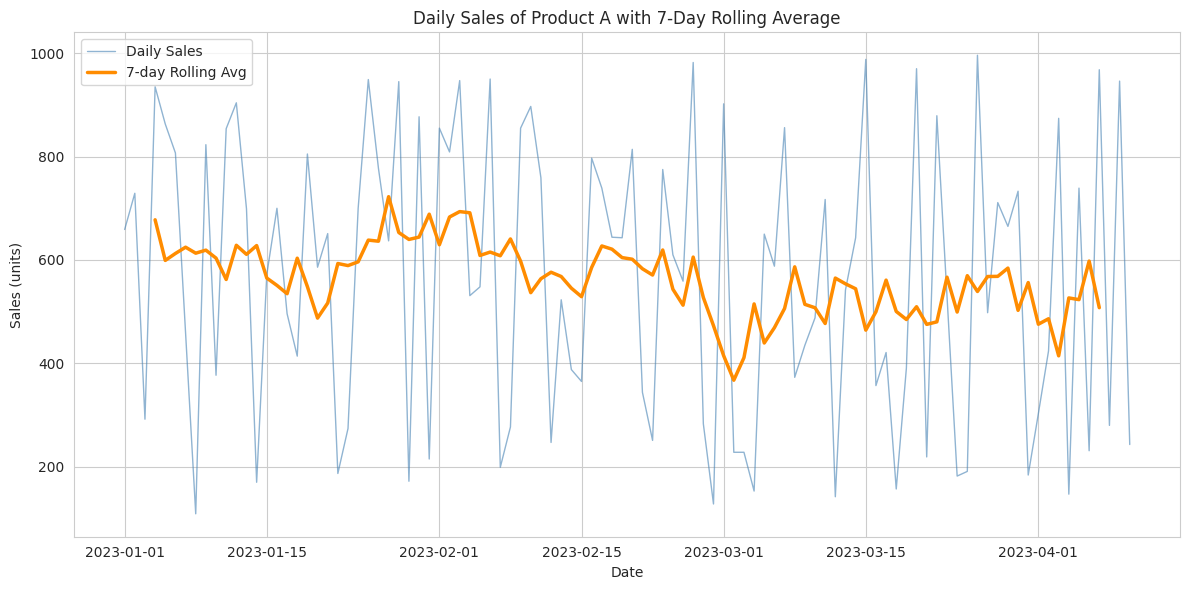

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# 1️⃣  Load / prepare the data (replace with your own source)
# -------------------------------------------------
# df = pd.read_csv('your_file.csv', parse_dates=['Date'])
# For the purpose of this snippet we assume `df` already exists
df['Date'] = pd.to_datetime(df['Date'])

# -------------------------------------------------
# 2️⃣  Compute a 7‑day rolling mean for smoothing
# -------------------------------------------------
df = df.sort_values('Date')
df['Sales_RollMean7'] = df['Sales'].rolling(window=7, center=True).mean()

# -------------------------------------------------
# 3️⃣  Plot – daily sales + rolling mean
# -------------------------------------------------
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')

# Daily sales as a faint line (or points)
sns.lineplot(
    data=df,
    x='Date',
    y='Sales',
    color='steelblue',
    linewidth=1,
    label='Daily Sales',
    alpha=0.6
)

# 7‑day rolling mean as a bold line
sns.lineplot(
    data=df,
    x='Date',
    y='Sales_RollMean7',
    color='darkorange',
    linewidth=2.5,
    label='7‑day Rolling Avg'
)

# -------------------------------------------------
# 4️⃣  Highlight extreme outliers ( > 2σ from the mean )
# -------------------------------------------------
sales_mean = df['Sales'].mean()
sales_std  = df['Sales'].std()
outlier_mask = (df['Sales'] > sales_mean + 2*sales_std) | (df['Sales'] < sales_mean - 2*sales_std)

sns.scatterplot(
    data=df[outlier_mask],
    x='Date',
    y='Sales',
    color='red',
    s=80,
    marker='X',
    label='Outliers (±2σ)'
)

# -------------------------------------------------
# 5️⃣  Final touches
# -------------------------------------------------
plt.title('Daily Sales of Product A with 7‑Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Sales (units)')
plt.legend()
plt.tight_layout()
plt.show()